# 1. 标题与学习目标：DeepLOB 注释版

对应论文：**DeepLOB: Deep Convolutional Neural Networks for Limit Order Books**  
论文链接（arXiv）：https://arxiv.org/abs/1808.03668

本节要解决的核心问题：

- 如何把 FI-2010 的原始 LOB 数据组织成可训练的监督学习样本
- DeepLOB 为什么只使用前 40 维 raw LOB，且如何构造成 `(num_samples, 100, 40)`
- 如何完成一个可复现的训练-验证-测试闭环并解读结果

学习完成后，你将能够：

- 说清楚 LOB 数据在本任务中的输入输出定义
- 理解为什么 DeepLOB 只使用前 40 维 raw LOB
- 理解样本如何从 `(149, N)` 转换为 `(num_samples, 100, 40)`
- 跑通一个最小可复现实验，并读懂 loss/acc 与分类报告

## 2. 研究背景与直觉

本 notebook 使用 **FI-2010** 限价订单簿（Limit Order Book, LOB）基准数据集，并参照论文 *DeepLOB: Deep Convolutional Neural Networks for Limit Order Books* 的实验设置。

- 任务目标：预测中间价（mid-price）未来方向
- 任务形式：三分类（上涨 / 平稳 / 下跌）
- 数据特点：高频、事件驱动、强时序依赖、类别分布可能不均衡

任务动机（直觉）是：

- 单个时刻盘口是“静态快照”，信息有限
- 连续盘口序列包含微观结构演化信号
- DeepLOB 通过 CNN + Inception + LSTM 联合建模局部结构与时序依赖

## 5. 数据集与任务定义（概览）

当前目录中的典型文件包括：

- `Train_Dst_NoAuction_DecPre_CF_7.txt`（训练）
- `Test_Dst_NoAuction_DecPre_CF_7.txt`、`Test_Dst_NoAuction_DecPre_CF_8.txt`、`Test_Dst_NoAuction_DecPre_CF_9.txt`（测试）

在 DeepLOB 的常见处理流程中：

- 训练文件再按时间切一部分做验证集（例如 80/20）
- 多个测试文件按时间拼接为完整测试集
- 每个时间点（event）对应一列数据

这些 txt 通常是“**按行存特征**、**按列存时间事件**”的矩阵，而不是“每行一个样本”。

### 5.1 输入前 40 维（0~39）：raw LOB

对任意一个 event（txt 的某一列），前 40 维来自前 10 档盘口，每档 4 个值：

- 第 l 档（`l=1...10`）: `ask_price_l, ask_size_l, bid_price_l, bid_size_l`

展开顺序通常是：

`[ask_p1, ask_v1, bid_p1, bid_v1, ask_p2, ask_v2, bid_p2, bid_v2, ..., ask_p10, ask_v10, bid_p10, bid_v10]`

简化样例（只展示前 3 档，实际到 10 档）：

- 第 1 档：卖一价 101.20，卖一量 800，买一价 101.18，买一量 950
- 第 2 档：卖二价 101.22，卖二量 760，买二价 101.16，买二量 880
- 第 3 档：卖三价 101.24，卖三量 640，买三价 101.14，买三量 920

该 event 的前 12 维就是：

`[101.20, 800, 101.18, 950, 101.22, 760, 101.16, 880, 101.24, 640, 101.14, 920, ...]`

按 0-based 索引理解：

- 0~3: level-1 的 `[ask_p1, ask_v1, bid_p1, bid_v1]`
- 4~7: level-2 的 `[ask_p2, ask_v2, bid_p2, bid_v2]`
- ...
- 36~39: level-10 的 `[ask_p10, ask_v10, bid_p10, bid_v10]`

### 5.2 其他维度（40~143）：handcrafted features

这 104 维是基于 LOB 原始价量进一步构造的手工统计特征，通常用于传统机器学习基线。常见类别包括：

- 价差与价差变化
- 各档深度、累积深度与不平衡度（imbalance）
- 跨档价差、斜率、梯度
- 简单收益率/差分等短期动态统计

你可以把它理解成“研究者先验设计的摘要信号”。在 DeepLOB 主设定里，这部分保留在文件中，但模型输入通常不使用它们。

### 5.3 最后 5 行（144~148）：labels

最后 5 维是 5 个不同预测 horizon 的三分类标签（上涨/平稳/下跌）。

- 原始标签常见取值：`{1, 2, 3}`
- 训练时常映射为：`{0, 1, 2}`
- 第 k 个 horizon 的标签通常取 `y[:, k]`

FI-2010 常见定义里，5 个标签对应未来：

- `k=0 -> 10 events`
- `k=1 -> 20 events`
- `k=2 -> 30 events`
- `k=3 -> 50 events`
- `k=4 -> 100 events`

因此，如果原矩阵记为 `data`（形状 `(149, N)`）：

- raw LOB 输入: `data[:40, :].T`，形状 `(N, 40)`
- handcrafted: `data[40:144, :].T`，形状 `(N, 104)`
- 5 个标签: `data[144:149, :].T`，形状 `(N, 5)`

## 3. 模型框架（组件关系）

DeepLOB 的主干结构可以概括为：

- 卷积模块（CNN blocks）：提取局部价量结构
- Inception 模块：并行建模不同时间尺度模式
- LSTM 模块：建模更长时间依赖
- 全连接 + Softmax：输出三分类概率

## 4. 模型组件（组件内部）

在本 notebook 的实现中：

- `conv1/conv2/conv3`：逐步压缩特征宽度并提取时序局部模式
- `inp1/inp2/inp3`：不同卷积核与池化分支并行
- `lstm`：对融合后的时序表示做序列建模
- `fc1`：将隐藏状态映射到类别空间

## 6. 损失函数定义

本节使用 `CrossEntropyLoss`：

- 输入：模型输出 logits/概率与整数类别标签
- 目标：最小化分类误差
- 任务：三分类（下跌/平稳/上涨）

## 7. 模型训练过程

训练流程包括：

- 优化器：Adam（默认学习率 `1e-4`）
- 每个 epoch 记录：`train_loss`、`val_loss`、`train_acc`、`val_acc`
- 保存验证集最优模型：`best_val_model_pytorch.pth`
- 输出训练历史：`training_history.json`

## 8. 最小可运行示例与结果解释

本 notebook 提供可直接运行的最小流程：

1. 加载 FI-2010 txt 并构造 `(num_samples, 1, 100, 40)` 输入
2. 训练少量 epoch（可先用 `epochs=2` 快速验证）
3. 绘制 loss/acc 曲线
4. 在测试集输出 `test_loss`、`test_acc`
5. 输出 `classification_report` 观察各类 precision/recall/f1

读图与读指标时，建议重点关注：

- `train` 与 `val` 曲线是否同向下降（稳定性）
- 类别间 precision/recall 是否明显不均衡（类别偏置）

## 9. 小结

本节完成了从数据结构、任务定义到模型训练与评估的完整闭环。你可以先用较小 epoch 验证流程，再逐步扩展到更完整实验（更长训练、更多对比、加入回测解释）。

In [1]:
import numpy as np
import torch
from torch.utils import data


# -----------------------------
# 1. 特征与标签提取
# -----------------------------
def prepare_x(raw_data):
    """提取前 40 行 raw LOB 特征，并转置为 (N, 40)。"""
    return raw_data[:40, :].T


def get_label(raw_data):
    """提取最后 5 行标签，并转置为 (N, 5)。"""
    return raw_data[-5:, :].T


# -----------------------------
# 2. 滑动窗口样本构造
# -----------------------------
def build_sequence_samples(features, labels, window_size):
    """将逐时刻特征切成长度为 window_size 的序列样本。"""
    num_events, feature_dim = features.shape
    num_samples = num_events - window_size + 1

    sample_x = np.zeros((num_samples, window_size, feature_dim))
    sample_y = labels[window_size - 1:num_events]

    for idx in range(window_size, num_events + 1):
        sample_x[idx - window_size] = features[idx - window_size:idx, :]

    return sample_x, sample_y


# -----------------------------
# 3. PyTorch 数据集
# -----------------------------
class DeepLOBDataset(data.Dataset):
    """DeepLOB 的 PyTorch Dataset，输出形状为 (1, T, 40)。"""

    def __init__(self, raw_data, horizon_index=4, num_classes=3, window_size=100):
        self.horizon_index = horizon_index
        self.num_classes = num_classes
        self.window_size = window_size

        features = prepare_x(raw_data)
        labels = get_label(raw_data)
        features, labels = build_sequence_samples(features, labels, window_size)

        # 将标签从 {1, 2, 3} 映射到 {0, 1, 2}
        labels = labels[:, horizon_index] - 1

        self.x = torch.from_numpy(features).unsqueeze(1).float()
        self.y = torch.from_numpy(labels).long()
        self.length = len(self.x)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        return self.x[index], self.y[index]


# -----------------------------
# 4. 读取原始 txt 文件
# -----------------------------
train_raw = np.loadtxt('Train_Dst_NoAuction_DecPre_CF_7.txt')
test_raw_7 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_7.txt')
test_raw_8 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_8.txt')
test_raw_9 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_9.txt')

# 按时间顺序切分训练集：前 80% 做训练，后 20% 做验证
split_idx = int(np.floor(train_raw.shape[1] * 0.8))
train_raw_split = train_raw[:, :split_idx]
val_raw_split = train_raw[:, split_idx:]

# 将 3 个测试文件按列拼接成完整测试集
test_raw = np.hstack((test_raw_7, test_raw_8, test_raw_9))

print('原始矩阵形状：')
print('train_raw       =', train_raw.shape)
print('train_raw_split =', train_raw_split.shape)
print('val_raw_split   =', val_raw_split.shape)
print('test_raw_7      =', test_raw_7.shape)
print('test_raw_8      =', test_raw_8.shape)
print('test_raw_9      =', test_raw_9.shape)
print('test_raw        =', test_raw.shape)




原始矩阵形状：
train_raw       = (149, 254750)
train_raw_split = (149, 203800)
val_raw_split   = (149, 50950)
test_raw_7      = (149, 55478)
test_raw_8      = (149, 52172)
test_raw_9      = (149, 31937)
test_raw        = (149, 139587)


In [2]:
# -----------------------------
# 5. 构造 DeepLOB 数据集与 DataLoader
# -----------------------------
window_size = 100
horizon_index = 4  # 这里对应未来 100 个 event 的标签
num_classes = 3
batch_size = 64

train_dataset = DeepLOBDataset(
    train_raw_split,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)
val_dataset = DeepLOBDataset(
    val_raw_split,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)
test_dataset = DeepLOBDataset(
    test_raw,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)

print('\n样本张量形状：')
print('train_dataset.x =', train_dataset.x.shape)
print('train_dataset.y =', train_dataset.y.shape)
print('val_dataset.x   =', val_dataset.x.shape)
print('val_dataset.y   =', val_dataset.y.shape)
print('test_dataset.x  =', test_dataset.x.shape)
print('test_dataset.y  =', test_dataset.y.shape)

# 在 CUDA 下启用 pin_memory 可提升 Host -> Device 拷贝效率
pin_memory = torch.cuda.is_available()

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=pin_memory,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# 查看一个 batch 的形状，确认输入是否正确
xb, yb = next(iter(train_loader))
print('\n一个 batch 的形状：')
print('xb =', xb.shape)
print('yb =', yb.shape)


样本张量形状：
train_dataset.x = torch.Size([203701, 1, 100, 40])
train_dataset.y = torch.Size([203701])
val_dataset.x   = torch.Size([50851, 1, 100, 40])
val_dataset.y   = torch.Size([50851])
test_dataset.x  = torch.Size([139488, 1, 100, 40])
test_dataset.y  = torch.Size([139488])

一个 batch 的形状：
xb = torch.Size([64, 1, 100, 40])
yb = torch.Size([64])


In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [ ]:
import torch
import torch.nn as nn

class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        
        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        
        # inception moduels
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        
        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        # x: (B, 1, T, 40)
        h0 = torch.zeros(1, x.size(0), 64).to(device)  # (1, B, 64)
        c0 = torch.zeros(1, x.size(0), 64).to(device)  # (1, B, 64)
    
        x = self.conv1(x)  # (B, 32, T-6, 20)
        x = self.conv2(x)  # (B, 32, T-12, 10)
        x = self.conv3(x)  # (B, 32, T-18, 1)
        
        x_inp1 = self.inp1(x)  # (B, 64, T-18, 1)
        x_inp2 = self.inp2(x)  # (B, 64, T-18, 1)
        x_inp3 = self.inp3(x)  # (B, 64, T-18, 1)
        
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)  # (B, 192, T-18, 1)
        
        x = x.permute(0, 2, 1, 3)  # (B, T-18, 192, 1)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))  # (B, T-18, 192)
        
        x, _ = self.lstm(x, (h0, c0))  # (B, T-18, 64)
        x = x[:, -1, :]  # (B, 64)
        x = self.fc1(x)  # (B, y_len)
        forecast_y = torch.softmax(x, dim=1)  # (B, y_len)
        
        return forecast_y

In [5]:
from torchinfo import summary
model = deeplob(y_len = train_dataset.num_classes)
model.to(device)
summary(model, (1, 1, 100, 40))

Layer (type:depth-idx)                   Output Shape              Param #
deeplob                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 94, 20]           --
│    └─Conv2d: 2-1                       [1, 32, 100, 20]          96
│    └─LeakyReLU: 2-2                    [1, 32, 100, 20]          --
│    └─BatchNorm2d: 2-3                  [1, 32, 100, 20]          64
│    └─Conv2d: 2-4                       [1, 32, 97, 20]           4,128
│    └─LeakyReLU: 2-5                    [1, 32, 97, 20]           --
│    └─BatchNorm2d: 2-6                  [1, 32, 97, 20]           64
│    └─Conv2d: 2-7                       [1, 32, 94, 20]           4,128
│    └─LeakyReLU: 2-8                    [1, 32, 94, 20]           --
│    └─BatchNorm2d: 2-9                  [1, 32, 94, 20]           64
├─Sequential: 1-2                        [1, 32, 88, 10]           --
│    └─Conv2d: 2-10                      [1, 32, 94, 10]           2,080
│    └

In [6]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


def evaluate(model, data_loader, criterion, device):
    """在给定 data_loader 上评估 loss 和 accuracy。"""
    model.eval()
    loss_values = []
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
            targets = targets.to(device, dtype=torch.int64, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss_values.append(loss.item())
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    mean_loss = float(np.mean(loss_values)) if loss_values else 0.0
    accuracy = float(correct / total) if total > 0 else 0.0
    return mean_loss, accuracy


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """训练一个 epoch，返回 train_loss 和 train_acc。"""
    model.train()
    loss_values = []
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
        targets = targets.to(device, dtype=torch.int64, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        loss_values.append(loss.item())
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_loss = float(np.mean(loss_values)) if loss_values else 0.0
    train_acc = float(correct / total) if total > 0 else 0.0
    return train_loss, train_acc


def fit(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    """完整训练流程：每个 epoch 记录 train/val 的 loss 与 acc。"""
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }

    best_val_loss = np.inf
    best_val_epoch = -1

    for epoch in tqdm(range(epochs)):
        epoch_start = datetime.now()

        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            torch.save(model, './best_val_model_pytorch.pth')
            best_val_loss = val_loss
            best_val_epoch = epoch
            print('model saved')

        duration = datetime.now() - epoch_start
        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, "
            f"Val Acc: {val_acc:.4f}, "
            f"Duration: {duration}, "
            f"Best Val Epoch: {best_val_epoch}"
        )

    return history


def plot_training_curves(history):
    """绘制训练过程中的 loss/acc 曲线。"""
    epochs = np.arange(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], label='train loss')
    axes[0].plot(epochs, history['val_loss'], label='val loss')
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='train acc')
    axes[1].plot(epochs, history['val_acc'], label='val acc')
    axes[1].set_title('Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

  2%|▏         | 1/50 [00:17<14:14, 17.44s/it]

model saved
Epoch 1/50, Train Loss: 0.9106, Val Loss: 0.9680, Train Acc: 0.6213, Val Acc: 0.5570, Duration: 0:00:17.443633, Best Val Epoch: 0


  4%|▍         | 2/50 [00:34<13:44, 17.17s/it]

model saved
Epoch 2/50, Train Loss: 0.8179, Val Loss: 0.9206, Train Acc: 0.7231, Val Acc: 0.6130, Duration: 0:00:16.985489, Best Val Epoch: 1


  6%|▌         | 3/50 [00:51<13:18, 16.98s/it]

...

Epoch 48/50, Train Loss: 0.6511, Val Loss: 0.8787, Train Acc: 0.8998, Val Acc: 0.6643, Duration: 0:00:16.718214, Best Val Epoch: 15


 98%|█████████▊| 49/50 [13:42<00:16, 16.83s/it]

Epoch 49/50, Train Loss: 0.6507, Val Loss: 0.8828, Train Acc: 0.8999, Val Acc: 0.6604, Duration: 0:00:16.917097, Best Val Epoch: 15


100%|██████████| 50/50 [13:59<00:00, 16.79s/it]

Epoch 50/50, Train Loss: 0.6497, Val Loss: 0.8838, Train Acc: 0.9010, Val Acc: 0.6601, Duration: 0:00:16.739371, Best Val Epoch: 15
已保存 training_history.json
{
  "train_loss": [
    0.9105988077273954,
    0.8178880923654986,
    0.7879003015771963,
    0.7693517696471698,
    0.7567880161333639,
    0.7475339523322021,
    0.7395164947108281,
    0.7331123326396253,
    0.7269186132777385,
    0.7209861868962604,
    0.7163196239237736,
    0.7113724285950273,
    0.7076078981601177,
    0.7032730153923022,
    0.6997752923131026,
    0.6965885240627916,
    0.694839327282176,
    0.6911322091347086,
    0.6882020524564569,
    0.6862003872913645,
    0.6840677500295445,
    0.6819965802308638,
    0.6807343074258978,
    0.6782225640996836,
    0.6762339507600926,
    0.6754411764389083,
    0.672950408685668,
    0.671456266696671,
    0.6702048097284493,
    0.6685895701455425,
    0.6673705992629758,
    0.6659910879231009,
    0.6649156517290372,
    0.6639076952397954,
    0.661

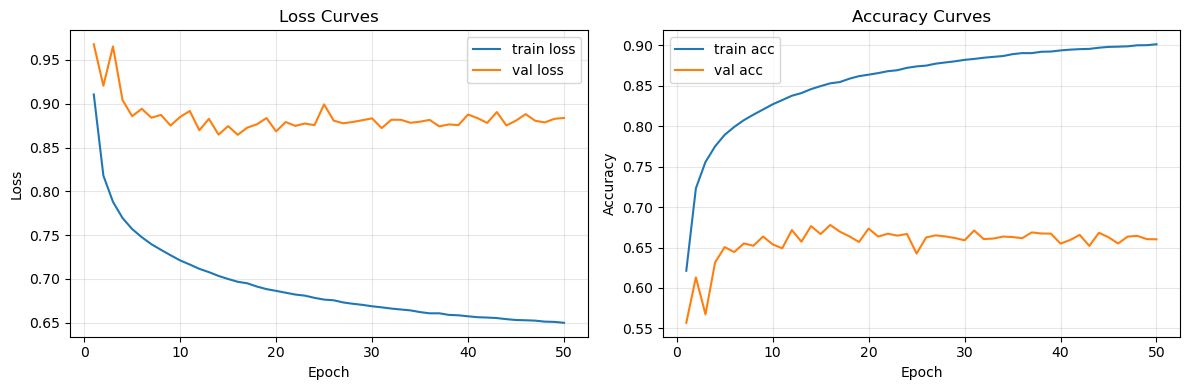

In [7]:
# 训练参数
learning_rate = 1e-4
epochs = 50

# 损失函数与优化器
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 开始训练（使用 val_loader 作为验证集）
history = fit(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    device=device,
)

# 以 JSON 形式保存与展示训练历史
history_json = json.dumps(history, ensure_ascii=False, indent=2)
with open('training_history.json', 'w', encoding='utf-8') as f:
    f.write(history_json)

print('已保存 training_history.json')
print(history_json)

# 绘制训练曲线
plot_training_curves(history)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

# 在测试集上评估保存的最佳模型
best_model = torch.load('best_val_model_pytorch.pth', map_location=device, weights_only=False)
best_model.to(device)

# 1) 复用 evaluate 计算 loss 和 acc
test_loss, test_acc = evaluate(
    model=best_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")

# 2) 收集全部标签与预测，输出 sklearn 评估报告
best_model.eval()
all_targets = []
all_predictions = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
        targets = targets.to(device, dtype=torch.int64, non_blocking=True)

        outputs = best_model(inputs)
        predictions = outputs.argmax(dim=1)

        all_targets.extend(targets.cpu().numpy().tolist())
        all_predictions.extend(predictions.cpu().numpy().tolist())

print('accuracy_score:', accuracy_score(all_targets, all_predictions))
print(classification_report(all_targets, all_predictions, digits=4))

Test loss: 0.7909
Test acc : 0.7534
accuracy_score: 0.7533694654737325
              precision    recall  f1-score   support

           0     0.7343    0.7437    0.7390     47915
           1     0.8238    0.7563    0.7886     48050
           2     0.7067    0.7608    0.7328     43523

    accuracy                         0.7534    139488
   macro avg     0.7550    0.7536    0.7535    139488
weighted avg     0.7566    0.7534    0.7541    139488

